# 01 - Non-Predictive Data Exploration

This notebook summarizes the DREAMT data artifacts used by the project before feature exploration or modeling. It is intentionally descriptive: it checks cohort size, split composition, epoch validity, label balance, signal missingness, recording durations, and raw-file schema availability.

This notebook does **not** ask which features predict sleep stage, compare feature families, tune models, or use the held-out test split to guide modeling choices. Those questions belong in later notebooks after the descriptive data contract is understood.

## Setup

The notebook can be run from either the repository root or the `notebooks/` directory. It uses committed code for project constants and reads generated CSV artifacts from `data/interim/`.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import EPOCH_SECONDS, RAW_SIGNAL_COLUMNS, SPLIT_ORDER
from src.data.load_dreamt import extract_participant_id, list_participant_csvs

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"

SPLIT_ASSIGNMENTS_PATH = INTERIM_DIR / "split_assignments.csv"
EPOCH_INDEX_PATH = INTERIM_DIR / "epoch_index.csv"

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/manns79/feature-engineered-wearable-sleep-staging


## Load Data Artifacts

`split_assignments.csv` defines participant-level train/validation/test membership. `epoch_index.csv` is the non-predictive summary of fixed 30-second epochs, including mapped labels, validity flags, exclusion reasons, and per-signal missingness fractions.

In [2]:
required_paths = {
    "split assignments": SPLIT_ASSIGNMENTS_PATH,
    "epoch index": EPOCH_INDEX_PATH,
}
missing_paths = [name for name, path in required_paths.items() if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Missing required artifact(s): "
        + ", ".join(missing_paths)
        + ". Run scripts/copy_previous_split.py and scripts/build_epoch_index.py first."
    )

split_assignments = pd.read_csv(SPLIT_ASSIGNMENTS_PATH, dtype={"participant_id": str})
epoch_index = pd.read_csv(EPOCH_INDEX_PATH, dtype={"participant_id": str})

split_assignments["participant_id"] = split_assignments["participant_id"].str.strip().str.upper()
split_assignments["split"] = split_assignments["split"].str.strip()
epoch_index["participant_id"] = epoch_index["participant_id"].str.strip().str.upper()
epoch_index["split"] = epoch_index["split"].str.strip()

def coerce_bool(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series
    return series.astype(str).str.strip().str.lower().isin({"true", "1", "yes"})

for bool_column in ["is_valid_label", "is_valid_epoch"]:
    if bool_column in epoch_index.columns:
        epoch_index[bool_column] = coerce_bool(epoch_index[bool_column])

split_order = [split for split in SPLIT_ORDER if split in set(split_assignments["split"])]
stage_order = ["Wake", "Non-REM", "REM"]
missingness_columns = [column for column in epoch_index.columns if column.startswith("missingness_")]

display(Markdown(f"Loaded **{len(split_assignments):,}** participant assignments and **{len(epoch_index):,}** fixed-length epochs."))
display(epoch_index.head())

Loaded **100** participant assignments and **105,960** fixed-length epochs.

,participant_id,split,epoch_id,start_row,end_row,n_rows,expected_n_rows,epoch_start_offset_rows,start_time,end_time,raw_label,mapped_label,is_valid_label,is_valid_epoch,exclusion_reason,missingness_BVP,missingness_ACC_X,missingness_ACC_Y,missingness_ACC_Z,missingness_TEMP,missingness_EDA,missingness_IBI,missingness_HR
0,S002,train,0,1536,3456,1920,1920,1536,24.0,53.984375,P,NaN,False,False,excluded_label,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,S002,train,1,3456,5376,1920,1920,1536,54.0,83.984375,P,NaN,False,False,excluded_label,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,S002,train,2,5376,7296,1920,1920,1536,84.0,113.984375,P,NaN,False,False,excluded_label,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,S002,train,3,7296,9216,1920,1920,1536,114.0,143.984375,P,NaN,False,False,excluded_label,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,S002,train,4,9216,11136,1920,1920,1536,144.0,173.984375,P,NaN,False,False,excluded_label,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Participant Counts by Split

Participant counts should be computed from the split assignment table, not from row counts, because splits are participant-level. The second table cross-checks participants represented in the epoch index against the split assignment table using human-readable statuses: `in_both_tables`, `epoch_index_only`, and `split_assignment_only`.


In [3]:
participant_counts = (
    split_assignments.groupby("split", observed=True)["participant_id"]
    .nunique()
    .reindex(split_order)
    .rename("n_participants")
    .to_frame()
)
participant_counts["share"] = participant_counts["n_participants"] / participant_counts["n_participants"].sum()

epoch_participants = epoch_index[["participant_id", "split"]].drop_duplicates()
split_cross_check = (
    epoch_participants.merge(
        split_assignments.rename(columns={"split": "assigned_split"}),
        on="participant_id",
        how="outer",
        indicator=True,
    )
    .assign(
        table_status=lambda df: df["_merge"].map(
            {
                "both": "in_both_tables",
                "left_only": "epoch_index_only",
                "right_only": "split_assignment_only",
            }
        ),
        split_matches=lambda df: df["split"].eq(df["assigned_split"]),
    )
    .sort_values(["table_status", "participant_id"])
)

display(participant_counts.style.format({"share": "{:.1%}"}))
display(split_cross_check["table_status"].value_counts().rename_axis("participant_status").to_frame("n_participants"))

mismatched = split_cross_check.loc[
    split_cross_check["table_status"].ne("in_both_tables") | ~split_cross_check["split_matches"].fillna(False)
]
if mismatched.empty:
    display(Markdown("All epoch-index participants match the split assignment table."))
else:
    display(Markdown("Participants needing split-assignment review:"))
    display(mismatched.drop(columns="_merge"))


,n_participants,share
split,,
train,70,70.0%
validation,15,15.0%
test,15,15.0%


,n_participants
participant_status,
in_both_tables,100
epoch_index_only,0
split_assignment_only,0


All epoch-index participants match the split assignment table.

## Epoch Counts by Split and Class

This section separates all indexed epochs from valid labeled epochs. Invalid epochs are useful for data-quality accounting but are excluded from downstream feature tables.

,total_epochs,valid_epochs,participants,excluded_epochs,valid_share
split,,,,,
train,73963,55839,70,18124,75.5%
validation,16031,12027,15,4004,75.0%
test,15966,12269,15,3697,76.8%


mapped_label,Wake,Non-REM,REM
split,,,
train,15196,34979,5664
validation,2110,8496,1421
test,2819,8132,1318


mapped_label,Wake,Non-REM,REM
split,,,
train,27.2%,62.6%,10.1%
validation,17.5%,70.6%,11.8%
test,23.0%,66.3%,10.7%


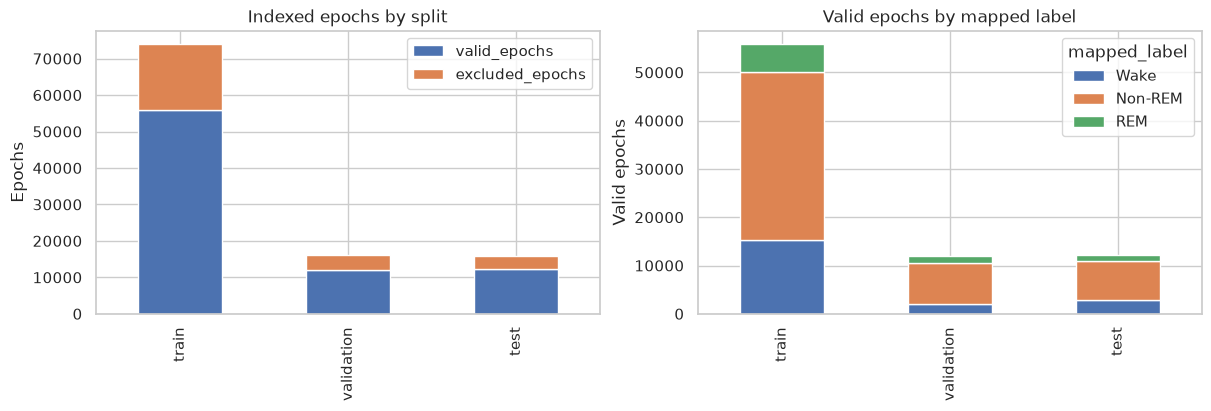

In [4]:
epoch_counts_by_split = (
    epoch_index.groupby("split", observed=True)
    .agg(
        total_epochs=("epoch_id", "size"),
        valid_epochs=("is_valid_epoch", "sum"),
        participants=("participant_id", "nunique"),
    )
    .reindex(split_order)
)
epoch_counts_by_split["excluded_epochs"] = epoch_counts_by_split["total_epochs"] - epoch_counts_by_split["valid_epochs"]
epoch_counts_by_split["valid_share"] = epoch_counts_by_split["valid_epochs"] / epoch_counts_by_split["total_epochs"]

valid_epochs = epoch_index.loc[epoch_index["is_valid_epoch"].astype(bool)].copy()
class_counts = (
    valid_epochs.pivot_table(
        index="split",
        columns="mapped_label",
        values="epoch_id",
        aggfunc="size",
        fill_value=0,
        observed=True,
    )
    .reindex(index=split_order, columns=stage_order, fill_value=0)
    .astype(int)
)
class_shares = class_counts.div(class_counts.sum(axis=1), axis=0)

display(epoch_counts_by_split.style.format({"valid_share": "{:.1%}"}))
display(class_counts)
display(class_shares.style.format("{:.1%}"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
epoch_counts_by_split[["valid_epochs", "excluded_epochs"]].plot(kind="bar", stacked=True, ax=axes[0])
axes[0].set_title("Indexed epochs by split")
axes[0].set_xlabel("")
axes[0].set_ylabel("Epochs")
class_counts.plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("Valid epochs by mapped label")
axes[1].set_xlabel("")
axes[1].set_ylabel("Valid epochs")
plt.show()

## Missingness by Signal

Missingness is summarized from the epoch-level missingness fractions generated while building the epoch index. The table reports all indexed epochs so missingness can be audited independently from label validity.

,mean,median,max,epochs_with_any_missing,epochs_fully_missing,share_with_any_missing,share_fully_missing
signal,,,,,,,
IBI,0.457%,0.000%,100.000%,531,455,0.501%,0.429%
BVP,0.000%,0.000%,0.000%,0,0,0.000%,0.000%
ACC_Y,0.000%,0.000%,0.000%,0,0,0.000%,0.000%
ACC_X,0.000%,0.000%,0.000%,0,0,0.000%,0.000%
ACC_Z,0.000%,0.000%,0.000%,0,0,0.000%,0.000%
TEMP,0.000%,0.000%,0.000%,0,0,0.000%,0.000%
EDA,0.000%,0.000%,0.000%,0,0,0.000%,0.000%
HR,0.000%,0.000%,0.000%,0,0,0.000%,0.000%


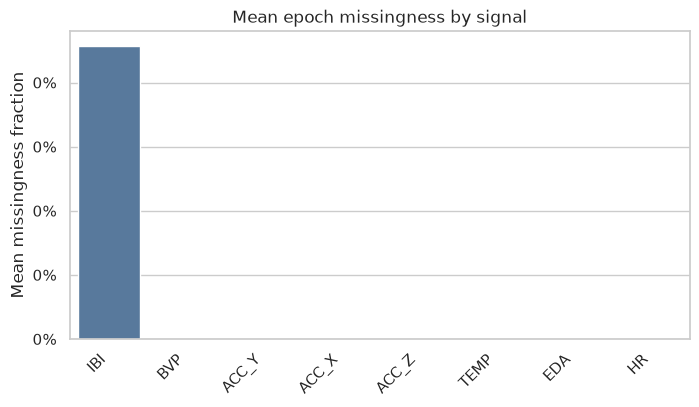

In [5]:
if not missingness_columns:
    display(Markdown("No epoch-level missingness columns were found in the epoch index."))
else:
    signal_missingness = (
        epoch_index[missingness_columns]
        .rename(columns=lambda column: column.removeprefix("missingness_"))
        .agg(["mean", "median", "max"])
        .T
        .rename_axis("signal")
        .sort_values("mean", ascending=False)
    )
    signal_missingness["epochs_with_any_missing"] = [
        int(epoch_index[f"missingness_{signal}"].gt(0).sum()) for signal in signal_missingness.index
    ]
    signal_missingness["epochs_fully_missing"] = [
        int(epoch_index[f"missingness_{signal}"].ge(1).sum()) for signal in signal_missingness.index
    ]
    signal_missingness["share_with_any_missing"] = signal_missingness["epochs_with_any_missing"] / len(epoch_index)
    signal_missingness["share_fully_missing"] = signal_missingness["epochs_fully_missing"] / len(epoch_index)

    display(
        signal_missingness.style.format(
            {
                "mean": "{:.3%}",
                "median": "{:.3%}",
                "max": "{:.3%}",
                "share_with_any_missing": "{:.3%}",
                "share_fully_missing": "{:.3%}",
            }
        )
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(data=signal_missingness.reset_index(), x="signal", y="mean", ax=ax, color="#4c78a8")
    ax.set_title("Mean epoch missingness by signal")
    ax.set_xlabel("")
    ax.set_ylabel("Mean missingness fraction")
    ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    plt.xticks(rotation=45, ha="right")
    plt.show()

## Recording Duration Summaries

Durations are estimated from indexed 30-second epochs. This is the duration represented in the project artifacts, not necessarily every raw row in the original files. Reporting both total and valid-labeled duration makes preparation and excluded periods visible.

,split,participant_id,total_epochs,valid_epochs,excluded_epochs,total_hours,valid_hours,excluded_hours
0,test,S010,1129,824,305,9.408333,6.866667,2.541667
1,test,S014,954,796,158,7.950000,6.633333,1.316667
2,test,S015,1236,955,281,10.300000,7.958333,2.341667
3,test,S016,1070,836,234,8.916667,6.966667,1.950000
4,test,S021,1077,796,281,8.975000,6.633333,2.341667


total_hours                                                    \
                 count      mean       std       min       25%       50%   
split                                                                      
train             70.0  8.805119  0.416856  7.258333  8.581250  8.837500   
validation        15.0  8.906111  0.409661  8.525000  8.720833  8.866667   
test              15.0  8.870000  0.695712  7.925000  8.383333  8.916667   

                                valid_hours                                \
                 75%        max       count      mean       std       min   
split                                                                       
train       9.047917   9.733333        70.0  6.647500  0.365860  5.925000   
validation  8.916667  10.283333        15.0  6.681667  0.545901  6.008333   
test        9.366667  10.300000        15.0  6.816111  0.460207  6.000000   

                                                   excluded_hours            \
                 25%       50%       75%       max          count      mean   
split                                                                         
train       6.406250  6.716667  6.908333  7.500000           70.0  2.157619   
validation  6.241667  6.625000  7.000000  7.841667           15.0  2.224444   
test        6.629167  6.833333  7.000000  7.958333           15.0  2.053889   

                                                                      
                 std       min       25%       50%     75%       max  
split                                                                 
train       0.448727  1.066667  1.827083  2.154167  2.4875  3.275000  
validation  0.485887  1.208333  1.854167  2.366667  2.6250  2.900000  
test        0.484316  1.250000  1.754167  2.091667  2.4625  2.666667

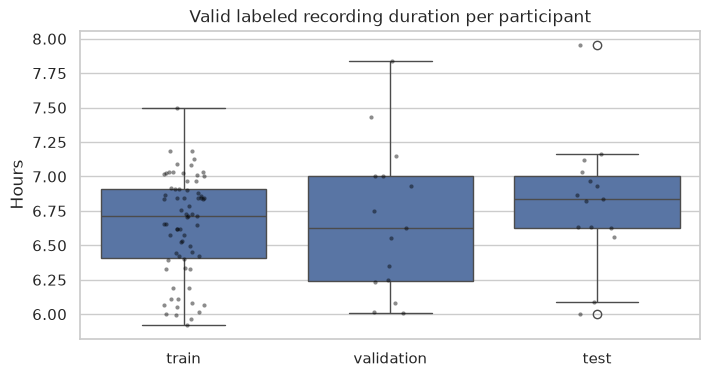

In [6]:
duration_by_participant = (
    epoch_index.groupby(["split", "participant_id"], observed=True)
    .agg(
        total_epochs=("epoch_id", "size"),
        valid_epochs=("is_valid_epoch", "sum"),
        excluded_epochs=("is_valid_epoch", lambda values: int((~values.astype(bool)).sum())),
    )
    .reset_index()
)
duration_by_participant["total_hours"] = duration_by_participant["total_epochs"] * EPOCH_SECONDS / 3600
duration_by_participant["valid_hours"] = duration_by_participant["valid_epochs"] * EPOCH_SECONDS / 3600
duration_by_participant["excluded_hours"] = duration_by_participant["excluded_epochs"] * EPOCH_SECONDS / 3600

duration_summary = (
    duration_by_participant.groupby("split", observed=True)[["total_hours", "valid_hours", "excluded_hours"]]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .reindex(split_order)
)

display(duration_by_participant.head())
display(duration_summary)

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=duration_by_participant, x="split", y="valid_hours", order=split_order, ax=ax)
sns.stripplot(data=duration_by_participant, x="split", y="valid_hours", order=split_order, ax=ax, color="black", alpha=0.45, size=3)
ax.set_title("Valid labeled recording duration per participant")
ax.set_xlabel("")
ax.set_ylabel("Hours")
plt.show()

## Label Distribution

The raw-label table shows the labels found before mapping. Labels joined with `|`, such as `N1|N2`, indicate that more than one raw label appeared inside a single 30-second epoch window. The mapped-label table shows only valid epochs in the project target labels: `Wake`, `Non-REM`, and `REM`.


In [7]:
raw_label_counts = (
    epoch_index.assign(raw_label=epoch_index["raw_label"].fillna("<missing>"))
    .pivot_table(index="raw_label", columns="split", values="epoch_id", aggfunc="size", fill_value=0, observed=True)
    .reindex(columns=split_order, fill_value=0)
    .astype(int)
    .sort_index()
)

mapped_label_counts = class_counts.copy()
mapped_label_counts.loc["Total"] = mapped_label_counts.sum(axis=0)
mapped_label_shares = class_shares.copy()

display(raw_label_counts)
display(mapped_label_counts)
display(mapped_label_shares.style.format("{:.1%}"))

split,train,validation,test
raw_label,,,
Missing,61,1,0
Missing|N2,1,0,0
Missing|W,2,0,0
N1,5769,1306,1724
N1|N2,44,0,0
N1|R,13,0,0
N1|W,17,0,0
N2,27272,6608,6179
N2|N3,2,0,0


mapped_label,Wake,Non-REM,REM
split,,,
train,15196,34979,5664
validation,2110,8496,1421
test,2819,8132,1318
Total,20125,51607,8403


mapped_label,Wake,Non-REM,REM
split,,,
train,27.2%,62.6%,10.1%
validation,17.5%,70.6%,11.8%
test,23.0%,66.3%,10.7%


## Signal Availability and Schema Checks

The first check verifies that the epoch index contains missingness columns for the expected wearable signals and no extra missingness columns. The optional raw-file check inspects local participant CSV headers and lightweight dtype samples when raw files are available. Raw DREAMT files are intentionally ignored by git, so this section is allowed to report that no local raw files were found.


In [8]:
expected_missingness_columns = [f"missingness_{signal}" for signal in RAW_SIGNAL_COLUMNS]
missing_epoch_missingness_columns = sorted(set(expected_missingness_columns) - set(epoch_index.columns))
unexpected_missingness_columns = sorted(set(missingness_columns) - set(expected_missingness_columns))

epoch_schema_check = pd.DataFrame(
    {
        "check": ["all expected signal missingness columns are present", "no unexpected missingness columns are present"],
        "passed": [not missing_epoch_missingness_columns, not unexpected_missingness_columns],
        "details": [missing_epoch_missingness_columns, unexpected_missingness_columns],
    }
)
display(epoch_schema_check)

raw_csvs = list_participant_csvs(RAW_DIR) if RAW_DIR.exists() else []
if not raw_csvs:
    display(Markdown(f"No raw participant CSVs were found under `{RAW_DIR}`. Skipping raw schema checks."))
else:
    schema_rows = []
    for csv_path in raw_csvs:
        sample = pd.read_csv(csv_path, nrows=256)
        participant_id = extract_participant_id(csv_path)
        missing_signals = sorted(set(RAW_SIGNAL_COLUMNS) - set(sample.columns))
        present_signals = [signal for signal in RAW_SIGNAL_COLUMNS if signal in sample.columns]
        non_numeric_signals = [
            signal
            for signal in present_signals
            if pd.to_numeric(sample[signal], errors="coerce").notna().sum() == 0 and sample[signal].notna().sum() > 0
        ]
        schema_rows.append(
            {
                "participant_id": participant_id,
                "file": csv_path.name,
                "n_sample_rows": len(sample),
                "n_columns": sample.shape[1],
                "missing_expected_signals": missing_signals,
                "non_numeric_signal_samples": non_numeric_signals,
                "has_sleep_stage": "Sleep_Stage" in sample.columns,
                "has_timestamp": "TIMESTAMP" in sample.columns,
            }
        )
    raw_schema = pd.DataFrame(schema_rows).sort_values("participant_id")
    display(raw_schema)
    raw_schema_summary = pd.Series(
        {
            "n_files": len(raw_schema),
            "files_missing_any_signal": int(raw_schema["missing_expected_signals"].map(bool).sum()),
            "files_with_non_numeric_signal_sample": int(raw_schema["non_numeric_signal_samples"].map(bool).sum()),
            "files_missing_sleep_stage": int((~raw_schema["has_sleep_stage"].astype(bool)).sum()),
            "files_missing_timestamp": int((~raw_schema["has_timestamp"].astype(bool)).sum()),
        },
        name="raw_schema_summary",
    ).to_frame()
    display(raw_schema_summary)


,check,passed,details
0,all expected signal missingness columns are pr...,True,[]
1,no unexpected missingness columns are present,True,[]


,participant_id,file,n_sample_rows,n_columns,missing_expected_signals,non_numeric_signal_samples,has_sleep_stage,has_timestamp
0,S002,S002_whole_df.csv,256,14,[],[],True,True
1,S003,S003_whole_df.csv,256,14,[],[],True,True
2,S004,S004_whole_df.csv,256,14,[],[],True,True
3,S005,S005_whole_df.csv,256,14,[],[],True,True
4,S006,S006_whole_df.csv,256,14,[],[],True,True
5,S007,S007_whole_df.csv,256,14,[],[],True,True
6,S008,S008_whole_df.csv,256,14,[],[],True,True
7,S009,S009_whole_df.csv,256,14,[],[],True,True
8,S010,S010_whole_df.csv,256,14,[],[],True,True
9,S011,S011_whole_df.csv,256,14,[],[],True,True


,raw_schema_summary
n_files,100
files_missing_any_signal,0
files_with_non_numeric_signal_sample,0
files_missing_sleep_stage,0
files_missing_timestamp,0


## Additional Descriptive Checks

These checks look for preparation issues that can affect reproducibility without interpreting model signal: fixed epoch length consistency, inferred epoch-offset behavior, and participant-level contribution imbalance.

In [9]:
epoch_length_check = (
    epoch_index.assign(matches_expected_rows=epoch_index["n_rows"].eq(epoch_index["expected_n_rows"]))
    .groupby("split", observed=True)
    .agg(
        total_epochs=("epoch_id", "size"),
        epochs_with_expected_rows=("matches_expected_rows", "sum"),
        min_rows=("n_rows", "min"),
        max_rows=("n_rows", "max"),
        expected_rows=("expected_n_rows", "median"),
    )
    .reindex(split_order)
)
epoch_length_check["share_expected_rows"] = epoch_length_check["epochs_with_expected_rows"] / epoch_length_check["total_epochs"]

offset_summary = (
    epoch_index.groupby(["split", "participant_id"], observed=True)["epoch_start_offset_rows"]
    .first()
    .reset_index()
    .groupby("split", observed=True)["epoch_start_offset_rows"]
    .describe()
    .reindex(split_order)
)

participant_contribution = duration_by_participant.copy()
participant_contribution["valid_epoch_share_within_split"] = participant_contribution.groupby("split", observed=True)["valid_epochs"].transform(lambda values: values / values.sum())
largest_contributors = (
    participant_contribution.sort_values(["split", "valid_epoch_share_within_split"], ascending=[True, False])
    .groupby("split", observed=True)
    .head(5)
    .loc[:, ["split", "participant_id", "valid_epochs", "valid_hours", "valid_epoch_share_within_split"]]
)

display(epoch_length_check.style.format({"share_expected_rows": "{:.1%}"}))
display(offset_summary)
display(largest_contributors.style.format({"valid_hours": "{:.2f}", "valid_epoch_share_within_split": "{:.1%}"}))

,total_epochs,epochs_with_expected_rows,min_rows,max_rows,expected_rows,share_expected_rows
split,,,,,,
train,73963,73963,1920,1920,1920.000000,100.0%
validation,16031,16031,1920,1920,1920.000000,100.0%
test,15966,15966,1920,1920,1920.000000,100.0%


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
train,70.0,917.028571,586.035241,0.0,448.0,864.0,1456.0,1856.0
validation,15.0,981.333333,442.524360,448.0,608.0,960.0,1312.0,1664.0
test,15.0,571.733333,513.407589,0.0,192.0,512.0,864.0,1536.0


,split,participant_id,valid_epochs,valid_hours,valid_epoch_share_within_split
2,test,S015,955,7.96,7.8%
12,test,S069,860,7.17,7.0%
10,test,S056,854,7.12,7.0%
8,test,S044,844,7.03,6.9%
3,test,S016,836,6.97,6.8%
43,train,S043,900,7.50,1.6%
28,train,S022,862,7.18,1.5%
82,train,S100,862,7.18,1.5%
23,train,S012,855,7.12,1.5%
62,train,S074,851,7.09,1.5%


## Reproducibility Notes

- Keep this notebook descriptive and rerunnable from generated CSV artifacts.
- Rebuild `data/interim/epoch_index.csv` before rerunning this notebook if raw files, split assignments, epoch length assumptions, label mapping, or missingness thresholds change.
- Do not use these summaries to select features, tune model families, or revise the held-out test split. Use later notebooks and training scripts for model-facing analysis.